# Math for ML — Part 1. Basics of linear algebra and analytic geometry
#### [Math for ML - Part 2. Math for ML - Part 2. Basics of calculus (MatAn)](https://www.kaggle.com/code/kupershtein/math-for-ml-part-2-basics-of-calculus-matan)


## Why linear algebra and analytic geometry matter in ML¶

Linear algebra and analytic geometry are among the core mathematical foundations of machine learning because data, model parameters, and model operations are usually expressed in terms of vectors, matrices, and geometry.

A dataset can be organized as a matrix, features can be represented as vectors, and learning often means applying transformations in high-dimensional spaces.

**This requires understanding**:

- how vectors and matrices represent information;
- how linear transformations act on data;
- how distances, angles, and projections are defined;
- how coordinate geometry helps describe structure in space;
- how these ideas support model building, training, and interpretation.

## The core idea

Machine learning is often the problem of working with data in vector spaces, and linear algebra together with analytic geometry gives us the language and tools to do that.

# 1. Vectors and Dot Product

### What is a vector?

A **vector** is an ordered collection of numbers.  
In machine learning, a vector usually represents **one object described by features**.

For example, suppose one person is described by:

- height = 180
- weight = 75
- age = 23

Then we can write this object as the vector

$$
x = [180, 75, 23]
$$

### Why is this important in ML?

Vectors are everywhere in machine learning:

- in **linear regression**, each object is a vector of features;
- in **logistic regression**, predictions depend on a weighted combination of features;
- in **neural networks**, inputs, weights, and activations are vectors or matrices;
- in **embeddings**, words, images, and documents are represented as vectors in high-dimensional space.

### Dot product

For two vectors $a$ and $b$, the dot product is

$$
a \cdot b = \sum_i a_i b_i
$$

### Geometric intuition

The dot product tells us how aligned two vectors are:

- large positive value $\rightarrow$ similar direction;
- zero $\rightarrow$ orthogonal directions;
- negative value $\rightarrow$ opposite directions.

$$
a \cdot b = ||a|| \, ||b|| \cos(\theta)
$$

### Quick check

1. If two vectors are orthogonal, what is their dot product?  
2. If the angle between two vectors is small, will the dot product tend to be large or small?  
3. In the expression $w^T x + b$, what does $w$ represent?


### Common mistakes

- Thinking that vectors are only arrows in 2D or 3D.
- Memorizing the dot product formula without understanding that it measures alignment.
- Forgetting that feature scales affect dot-product-based models.

### Visual analogy

You can think of the dot product as a **direction agreement score**.

### ML takeaway

The dot product is one of the core mathematical operations behind linear models, neural network layers, similarity measures, and geometric reasoning in ML.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

In [2]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

dot_product = np.dot(a, b)
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
cos_theta = dot_product / (norm_a * norm_b)

print("a =", a)
print("b =", b)
print("Dot product a·b =", dot_product)
print("||a|| =", norm_a)
print("||b|| =", norm_b)
print("cos(theta) =", cos_theta)

x = np.array([180, 75, 23])
w = np.array([0.02, 0.03, -0.1])
b0 = 1.5
print("Linear score w^T x + b =", np.dot(w, x) + b0)

a = [1 2 3]
b = [4 5 6]
Dot product a·b = 32
||a|| = 3.7416573867739413
||b|| = 8.774964387392123
cos(theta) = 0.9746318461970762
Linear score w^T x + b = 5.049999999999999


# 2. Matrices and Matrix Multiplication

X shape: (3, 3)
W shape: (3, 2)
Y = X @ W
[[ 2.9  30.11]
 [ 2.4  28.47]
 [ 2.95 31.6 ]]


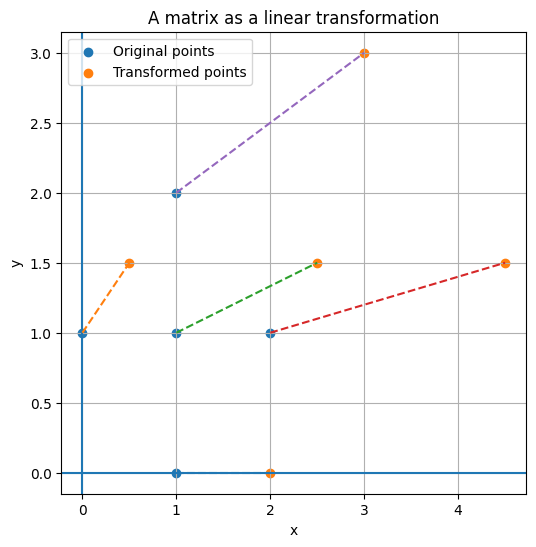

In [3]:
X = np.array([[180, 75, 23],
              [165, 60, 21],
              [190, 85, 30]], dtype=float)

W = np.array([[0.01, 0.20],
              [0.03, -0.10],
              [-0.05, 0.07]])

Y = X @ W
print("X shape:", X.shape)
print("W shape:", W.shape)
print("Y = X @ W")
print(Y)

points = np.array([[1, 0], [0, 1], [1, 1], [2, 1], [1, 2]], dtype=float)
A = np.array([[2.0, 0.5], [0.0, 1.5]])
transformed = points @ A.T

plt.figure(figsize=(6, 6))
plt.axhline(0)
plt.axvline(0)
plt.scatter(points[:, 0], points[:, 1], label="Original points")
plt.scatter(transformed[:, 0], transformed[:, 1], label="Transformed points")
for i in range(len(points)):
    plt.plot([points[i, 0], transformed[i, 0]], [points[i, 1], transformed[i, 1]], linestyle="--")
plt.legend()
plt.title("A matrix as a linear transformation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# 3. Systems of Linear Equations

### What is a system of linear equations?

A system of linear equations can be written as

$$
Ax = b
$$

### Connection to linear regression

In linear regression, one classical form of the solution is based on the normal equations:

$$
X^T X w = X^T y
$$

### Geometry of least squares

When we approximate the vector $y$ using the columns of the matrix $X$, we look for a projection $\hat{y}$ such that the error

$$
y - \hat{y}
$$

is orthogonal to the space spanned by the columns of $X$.

This is a fundamental geometric idea behind regression.

### Quick check

1. What do the columns of $X$ represent in linear regression?  
2. Why is solving $Ax = b$ relevant for ML?  
3. In least squares, what is special about the residual vector?

### Common mistakes

- Believing every system has a unique solution.
- Using matrix inversion blindly without thinking about numerical stability.
- Missing the geometric meaning of the least squares solution.

### ML takeaway

Least squares is not only an algebraic procedure. It is also the geometry of projection onto a subspace.

In [4]:
A = np.array([[2, 1],
              [1, -1]], dtype=float)
b = np.array([5, 1], dtype=float)
x = np.linalg.solve(A, b)
print("Solution:", x)

X_simple = np.array([[1, 1],
                     [1, 2],
                     [1, 3],
                     [1, 4]], dtype=float)
y_simple = np.array([2, 3, 5, 4], dtype=float)
w_hat = np.linalg.inv(X_simple.T @ X_simple) @ X_simple.T @ y_simple
print("Estimated parameters [bias, weight]:", w_hat)

Solution: [2. 1.]
Estimated parameters [bias, weight]: [1.5 0.8]


# 4. Basis, Linear Independence, and Rank

### Basis

A **basis** is a minimal set of vectors that can generate all vectors in a space.

### Linear independence

A set of vectors is **linearly independent** if none of the vectors can be written as a linear combination of the others.

### Rank

The **rank** of a matrix is the number of linearly independent rows or columns.

### Quick check

1. If one column is an exact multiple of another, are they linearly independent?  
2. What does rank tell us about a dataset matrix?  
3. Why can redundant features be problematic?

### Common mistakes

- Confusing the number of columns with the rank.
- Thinking that more features always mean more information.
- Ignoring multicollinearity in linear models.

### ML takeaway

Rank and independence help you understand how much real information is present in your features.

In [5]:
v1 = np.array([1, 2])
v2 = np.array([2, 4])
v3 = np.array([1, 0])

M = np.column_stack([v1, v2, v3])
print("Matrix M:")
print(M)
print("Rank of M =", np.linalg.matrix_rank(M))

X_rank = np.array([[1, 2, 3],
                   [2, 4, 6],
                   [3, 6, 9],
                   [4, 8, 12]], dtype=float)
print("Rank of X_rank =", np.linalg.matrix_rank(X_rank))
print("Shape of X_rank =", X_rank.shape)

Matrix M:
[[1 2 1]
 [2 4 0]]
Rank of M = 2
Rank of X_rank = 1
Shape of X_rank = (4, 3)


# 5. Orthogonality and Projections

# Orthogonality

Two vectors are orthogonal if their dot product is zero:

$$
a \cdot b = 0
$$

### Projection

$$
\text{proj}_u(x) = \frac{x \cdot u}{u \cdot u} u
$$

### Why least squares is geometric

When we approximate a target using a subspace, we are looking for the closest point in that subspace.  
That “closest point” is exactly a projection.

### Quick check

1. What does it mean geometrically if two vectors are orthogonal?  
2. What does projection keep, and what does it remove?  
3. Why is projection useful in regression?


### Common mistakes

- Thinking orthogonal means “far apart” instead of “at right angles”.
- Forgetting that projection depends on the chosen direction or subspace.
- Missing that the residual after projection is orthogonal to the subspace.

### Visual analogy

A projection is like a **shadow cast by a light source**.

### ML takeaway

Projection is one of the key geometric ideas behind regression, dimensionality reduction, and representation learning.

Projection of x onto u = [3. 0.]
Orthogonal component = [0. 2.]
Dot(orthogonal_part, u) = 0.0


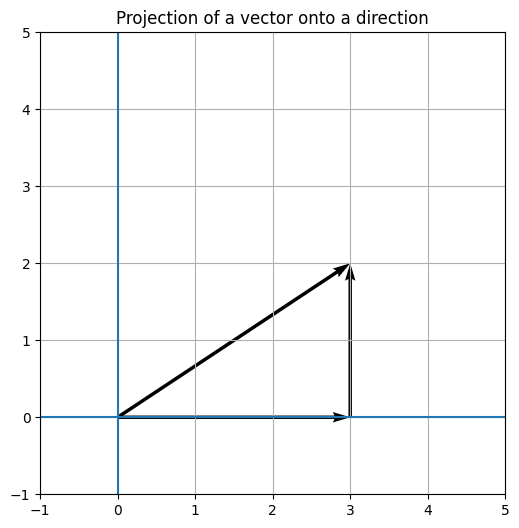

In [6]:
x = np.array([3.0, 2.0])
u = np.array([1.0, 0.0])

proj = (np.dot(x, u) / np.dot(u, u)) * u
orthogonal_part = x - proj

print("Projection of x onto u =", proj)
print("Orthogonal component =", orthogonal_part)
print("Dot(orthogonal_part, u) =", np.dot(orthogonal_part, u))

plt.figure(figsize=(6, 6))
plt.axhline(0)
plt.axvline(0)
plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, proj[0], proj[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(proj[0], proj[1], orthogonal_part[0], orthogonal_part[1], angles='xy', scale_units='xy', scale=1)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.grid(True)
plt.title("Projection of a vector onto a direction")
plt.show()

# 6. Eigenvalues and Eigenvectors

### Definition

For a matrix $A$, a nonzero vector $v$ is an eigenvector if

$$
Av = \lambda v
$$

where $\lambda$ is the corresponding eigenvalue.

### Quick check

1. What is preserved for an eigenvector after multiplication by a matrix?  
2. What does a large eigenvalue mean in the covariance setting?  
3. Why are eigenvectors useful in PCA?

### Common mistakes

- Thinking every vector is an eigenvector.
- Memorizing the equation $Av = \lambda v$ without geometric meaning.
- Ignoring that eigenvectors depend on the matrix being studied.

### ML takeaway

Eigenvectors identify structurally important directions, and eigenvalues quantify their influence.

Matrix A:
[[3. 1.]
 [0. 2.]]

Eigenvalues:
[3. 2.]

Eigenvectors (as columns):
[[ 1.    -0.707]
 [ 0.     0.707]]


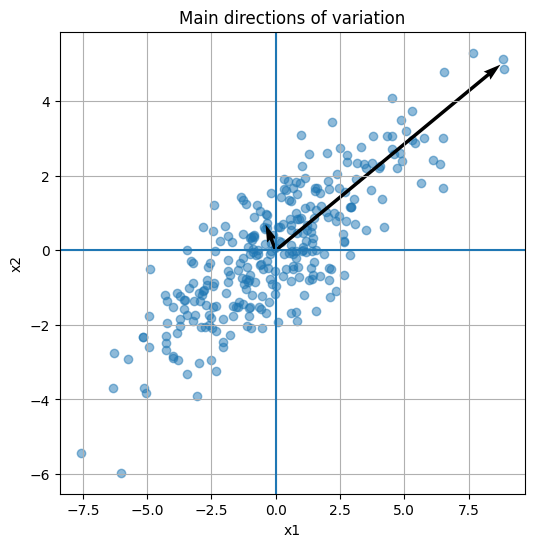

In [7]:
A = np.array([[3, 1],
              [0, 2]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
print("Matrix A:")
print(A)
print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors (as columns):")
print(eigenvectors)

rng = np.random.default_rng(42)
x1 = rng.normal(0, 3, 300)
x2 = 0.5 * x1 + rng.normal(0, 1, 300)
X2 = np.column_stack([x1, x2])
X_centered = X2 - X2.mean(axis=0)
cov = np.cov(X_centered.T)
eigvals, eigvecs = np.linalg.eig(cov)

plt.figure(figsize=(6, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5)
for i in range(2):
    vec = eigvecs[:, i] * eigvals[i]
    plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1)
plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.title("Main directions of variation")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# 7. SVD and PCA — Intuitive View

### Singular Value Decomposition (SVD)

For a matrix $X$, we can write

$$
X = U \Sigma V^T
$$

### Connection between SVD and PCA

If $X$ is centered, then PCA can be obtained from SVD:

- the rows of $V^T$ give principal directions;
- the singular values tell us how important these directions are.

### Quick check

1. What does PCA try to maximize?  
2. Why are principal components orthogonal?  
3. What do singular values tell us?

### Common mistakes

- Thinking PCA is just a plotting trick.
- Applying PCA without centering the data first.
- Confusing principal components with original features.

### ML takeaway

PCA and SVD help reveal the most informative structure in data while reducing redundancy and noise.

Singular values:
[54.852 15.46 ]
Principal directions (rows of VT):
[[-0.869 -0.495]
 [-0.495  0.869]]
Explained variance ratio: [0.926 0.074]


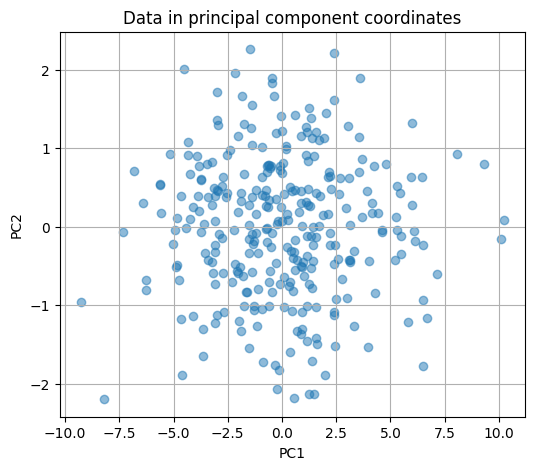

In [8]:
rng = np.random.default_rng(42)
x1 = rng.normal(0, 3, 300)
x2 = 0.5 * x1 + rng.normal(0, 1, 300)
X2 = np.column_stack([x1, x2])
X_centered = X2 - X2.mean(axis=0)

U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
print("Singular values:")
print(S)
print("Principal directions (rows of VT):")
print(VT)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X2)
print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title("Data in principal component coordinates")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# 8. Hyperplanes, Distances, and the Geometry of Classification

### What is a hyperplane?

A hyperplane can be written as

$$
w^T x + b = 0
$$

### Distance from a point to a hyperplane

For a point $x_0$, the distance to the hyperplane $w^T x + b = 0$ is

$$
d = \frac{|w^T x_0 + b|}{||w||}
$$

### Quick check

1. What is the role of $w$ in the equation $w^T x + b = 0$?  
2. Why is the distance to the boundary useful?  
3. Which models rely on linear decision boundaries?

### Common mistakes

- Thinking hyperplanes only exist in 2D or 3D.
- Forgetting that $w$ is normal to the boundary, not tangent to it.
- Interpreting classification only algebraically and ignoring the geometry.

### Visual analogy

A hyperplane is like a **decision wall** in space.

### ML takeaway

Many classifiers can be understood geometrically as learning where to place and orient a separating boundary in feature space.

w = [1.675 1.656]
b = -8.220901891824491


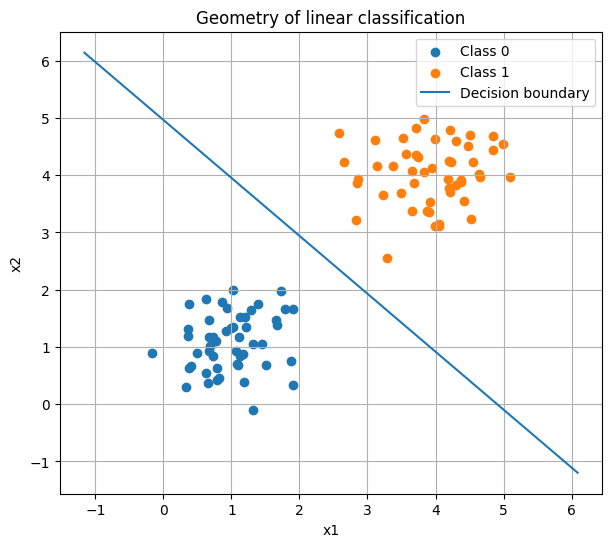

Distance to the decision boundary = 0.39739862483775695


In [9]:
rng = np.random.default_rng(0)
class_0 = rng.normal(loc=[1, 1], scale=0.5, size=(50, 2))
class_1 = rng.normal(loc=[4, 4], scale=0.6, size=(50, 2))
X_cls = np.vstack([class_0, class_1])
y_cls = np.array([0] * 50 + [1] * 50)

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_cls, y_cls)
w = clf.coef_[0]
b = clf.intercept_[0]
print("w =", w)
print("b =", b)

plt.figure(figsize=(7, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], label="Class 0")
plt.scatter(class_1[:, 0], class_1[:, 1], label="Class 1")
x_vals = np.linspace(X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1, 100)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, label="Decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Geometry of linear classification")
plt.legend()
plt.grid(True)
plt.show()

x0 = np.array([2.5, 3.0])
distance = abs(np.dot(w, x0) + b) / np.linalg.norm(w)
print("Distance to the decision boundary =", distance)

# Cheat Sheet

## Dot product

$$
a \cdot b = \sum_i a_i b_i
$$

$$
a \cdot b = ||a|| \, ||b|| \cos(\theta)
$$

## Matrix multiplication

$$
Y = XW
$$

## Linear system

$$
Ax = b
$$

## Normal equations

$$
X^T X w = X^T y
$$

## Projection

$$
\text{proj}_u(x) = \frac{x \cdot u}{u \cdot u} u
$$

## Eigenvector equation

$$
Av = \lambda v
$$

## SVD

$$
X = U \Sigma V^T
$$

## Hyperplane

$$
w^T x + b = 0
$$

## Distance to a hyperplane

$$
d = \frac{|w^T x_0 + b|}{||w||}
$$

# Mini Practice

1. Create two vectors and compute their dot product and cosine similarity.  
2. Create a data matrix of shape $(5, 3)$ and a weight matrix of shape $(3, 2)$.  
3. Find the rank of a matrix with one redundant column.  
4. Project the vector $(4, 3)$ onto the direction $(1, 1)$.  
5. Generate a 2D dataset, apply PCA, and inspect the explained variance ratio.

#### [Math for ML - Part 2. Math for ML - Part 2. Basics of calculus (MatAn)](https://www.kaggle.com/code/kupershtein/math-for-ml-part-2-basics-of-calculus-matan)